# 00_intro — Emulator Edition

This notebook is a 1:1 port of `00_intro.ipynb` that runs against the
Verilator emulator instead of a physical RFSoC. Every cell that would
normally invoke `prog.acquire()` or `prog.acquire_decimated()` against a
live `QickSoc` is replaced with the emulator flow:

```
OUT     = ARTIFACTS_ROOT / '<name>'
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)
if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)
iq_list = emu.load_iq_decimated(OUT, prog)   # or load_iq_averaged(...)
```

**Skipped cells:**
- DDR4 buffer cells (`24, 25, 26`) — the TB does not instantiate the DDR4
  buffer IP.
- "Ways to run programs" + scratchwork section (`58+`) — covered by the
  build helpers above.

## Setup

In [6]:
import sys
import importlib
import pathlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# path setup
REPO_ROOT  = pathlib.Path.cwd().parent          # emulator/
source_dir = REPO_ROOT / 'software' / 'source'
if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))

import qick_emu
importlib.reload(qick_emu)          # pick up edits without kernel restart
from qick_emu import QickEmu

from qick.asm_v2 import AveragerProgramV2, QickSpan, QickSweep1D

# emulator init
CFG_PATH = REPO_ROOT / 'notebooks' / 'qick_config_216.json'
emu      = QickEmu(str(CFG_PATH))
soccfg   = emu.soccfg

# artifact root
ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / '00_intro'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

# Master switch — set False to skip Verilator runs and re-plot from existing CSVs
RUN_SIM = True

print(f'REPO_ROOT     : {REPO_ROOT}')
print(f'ARTIFACTS_ROOT: {ARTIFACTS_ROOT}')
print(soccfg)

QICK library version mismatch: 0.2.366 remote (the board), 0.2.370 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


REPO_ROOT     : /Users/sbf/Desktop/to_verilate/emulator
ARTIFACTS_ROOT: /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro
QICK running on ZCU216, software version 0.2.366

Firmware configuration (built Sat Sep 28 22:15:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 32768 complex samples (3.419 us)
		32-bit DD

In [7]:
# ZCU216 standard firmware channel assignments
GEN_CH    = 0
RO_CH     = 0
TRIG_TIME = 0.40   # us
FREQ      = 100    # MHz

## Basic multi-pulse program

Port of `00_intro.ipynb` cell 10. Five pulses of different styles back-to-back
through a single RO window.

In [4]:
class MultiPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = 0.2
        self.add_gauss(ch=gen_ch, name='ramp',
                       sigma=ramp_len/10, length=ramp_len, even_length=True)

        self.add_pulse(ch=gen_ch, name='myflattop', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.1, phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch, name='mygaus', ro_ch=ro_ch,
                       style='arb', envelope='ramp',
                       freq=cfg['freq'], phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch, name='myconst', ro_ch=ro_ch,
                       style='const', length=0.2,
                       freq=cfg['freq'], phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch, name='myflattop2', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.1, phase=90, gain=1.0)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        # NB: `ddr4=True` is a no-op in the emulator — kept so the program
        # matches the on-hardware version byte-for-byte.
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name='myflattop',  t=0)
        self.pulse(ch=cfg['gen_ch'], name='mygaus',     t=0.4)
        self.pulse(ch=cfg['gen_ch'], name='myconst',    t=0.8)
        self.pulse(ch=cfg['gen_ch'], name='myflattop2', t=1.2)
        self.pulse(ch=cfg['gen_ch'], name='mygaus',     t=1.6)


config = {
    'gen_ch':    GEN_CH,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    1.9,
}

prog = MultiPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

# emulator artifacts
OUT = ARTIFACTS_ROOT / 'multi_pulse'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)
print(f'Artifacts → {OUT}')

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/multi_pulse/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

Artifacts → /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/multi_pulse


### Simulate & plot (MultiPulse)

[verilate] Building tb_qick_emu_verilator ...
verilator --binary --exe --build -j 0 -Wall --trace-vcd --Wno-fatal --timing -Wno-DECLFILENAME -Wno-PINCONNECTEMPTY -Wno-VARHIDDEN -Wno-TIMESCALEMOD -Wno-EOFNEWLINE -Wno-WIDTH -Wno-PINMISSING -Wno-BADVLTPRAGMA -Wno-CONSTRAINTIGN -I../../../firmware/pulp_platform/axi/include -I../../../firmware/pulp_platform/common_verification/include -I../../../firmware/pulp_platform/common_cells/include -I../../../firmware/ip/qick_processor/src -y ../../../emulator/models/bram_dp -y ../../../emulator/models/fifo -y ../../../emulator/models/dac_model -y ../../../emulator/models/sig_gen_dds -y ../../../emulator/models/sig_gen_dds/src -y ../../../firmware/ip/common -y ../../../firmware/ip/qick_common  verilator.vlt --top-module tb_qick_emu_verilator ../../../firmware/ip/axis_signal_gen_v6/src/axis_signal_gen_v6.v ../../../firmware/ip/axis_signal_gen_v6/src/latency_reg.v ../../../firmware/ip/axis_signal_gen_v6/src/signal_gen.v ../../../firmware/ip/axis_signal

%Warning-DEFOVERRIDE: ../../../emulator/models/bram_dp/../../../firmware/ip/qick_processor/src/_qproc_ips.sv:31:1: Overriding define: 'VERILATOR' with value: '' to existing command line define value: '1'
                      ... Location of previous definition, with value: '1'
                      ... For warning description see https://verilator.org/warn/DEFOVERRIDE?v=5.038
                      ... Use "/* verilator lint_off DEFOVERRIDE */" and lint_on around source to disable this message.
%Warning-MODDUP: ../../../emulator/models/bram_dp/../../../firmware/ip/axis_avg_buffer/src/verilog/fifo_sv.sv:1:8: Duplicate declaration of module: 'fifo_sv'
    1 | module fifo_sv #(
      |        ^~~~~~~
                 ../../../emulator/models/bram_dp/../../../firmware/ip/axis_dyn_readout_v1/src/fifo/verilog/fifo_sv.sv:1:8: ... Location of original declaration
    1 | module fifo_sv #(
      |        ^~~~~~~
                 ... For warning description see https://verilator.org/warn/MODDUP?

c++ -Os  -I.  -MMD -I/opt/homebrew/Cellar/verilator/5.038/share/verilator/include -I/opt/homebrew/Cellar/verilator/5.038/share/verilator/include/vltstd -DVM_COVERAGE=0 -DVM_SC=0 -DVM_TIMING=1 -DVM_TRACE=1 -DVM_TRACE_FST=0 -DVM_TRACE_VCD=1 -DVM_TRACE_SAIF=0 -faligned-new -fbracket-depth=4096 -fcf-protection=none -Xclang -fno-pch-timestamp -Qunused-arguments -Wno-bool-operation -Wno-c++11-narrowing -Wno-constant-logical-operand -Wno-non-pod-varargs -Wno-parentheses-equality -Wno-shadow -Wno-sign-compare -Wno-tautological-bitwise-compare -Wno-tautological-compare -Wno-uninitialized -Wno-unused-but-set-parameter -Wno-unused-but-set-variable -Wno-unused-parameter -Wno-unused-variable    -DVL_TIME_CONTEXT  -std=gnu++17 -std=gnu++20 -c -o verilated.o /opt/homebrew/Cellar/verilator/5.038/share/verilator/include/verilated.cpp
c++ -Os  -I.  -MMD -I/opt/homebrew/Cellar/verilator/5.038/share/verilator/include -I/opt/homebrew/Cellar/verilator/5.038/share/verilator/include/vltstd -DVM_COVERAGE=0 -DV

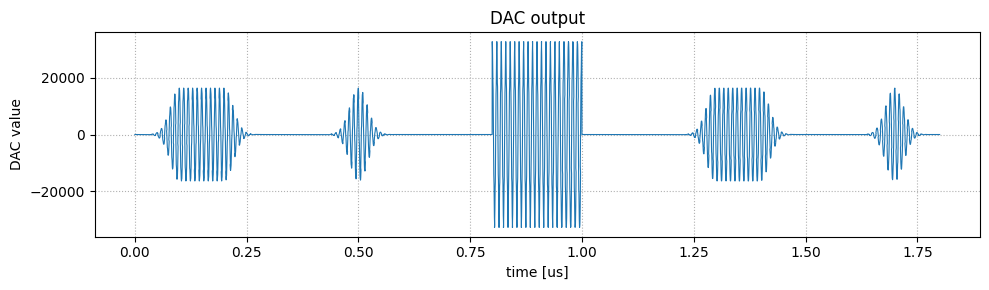

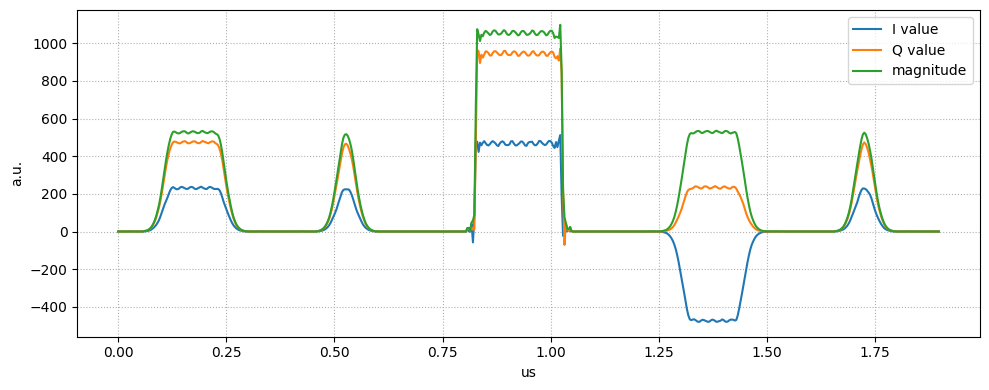

In [ ]:
if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=True, test_run_ns = 50)

# DAC waveform
t_dac, dac = emu.load_dac(OUT)
plt.figure(figsize=(10, 3))
plt.plot(t_dac, dac, linewidth=0.8)
plt.xlabel('time [us]'); plt.ylabel('DAC value'); plt.title('DAC output')
plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

# Decimated I/Q — mirror of cell 10 in 00_intro.ipynb
iq_list = emu.load_iq_decimated(OUT, prog)
t       = prog.get_time_axis(ro_index=0)

plt.figure(figsize=(10, 4))
plt.plot(t, iq_list[0][:, 0], label='I value')
plt.plot(t, iq_list[0][:, 1], label='Q value')
plt.plot(t, np.abs(iq_list[0].dot([1, 1j])), label='magnitude')
plt.xlabel('us'); plt.ylabel('a.u.')
plt.legend(); plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

In [ ]:
# print the program (ugly!)
print(prog)

## Basic sweep program

Port of `00_intro.ipynb` cells 13–18.

In [ ]:
class SimpleSweepProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop('myloop', cfg['steps'])

        self.add_gauss(ch=gen_ch, name='ramp',
                       sigma=cfg['ramp_len']/10, length=cfg['ramp_len'],
                       even_length=True)
        self.add_pulse(ch=gen_ch, name='mypulse', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=cfg['flat_len'],
                       phase=cfg['phase'], gain=cfg['gain'])

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

### 5-point phase+gain sweep, plot decimated I

In [ ]:
# Port of cell 14
config = {
    'steps':    5,
    'gen_ch':   GEN_CH,
    'ro_ch':    RO_CH,
    'freq':     FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':   0.35,
    'flat_len': 0.05,
    'ramp_len': 0.2,
    'phase':    QickSweep1D('myloop', -360, 720),
    'gain':     QickSweep1D('myloop',  0.0,  1.0),
}

prog = SimpleSweepProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'simple_sweep'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

t_dac, dac = emu.load_dac(OUT)
plt.figure(figsize=(10, 3))
plt.plot(t_dac, dac, linewidth=0.8)
plt.xlabel('us'); plt.ylabel('DAC value'); plt.title('DAC output')
plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

iq_list = emu.load_iq_decimated(OUT, prog)
iq_steps = iq_list[0]
if iq_steps.ndim == 2:
    iq_steps = iq_steps[None, :, :]
t = prog.get_time_axis(ro_index=0)
if len(t) != iq_steps.shape[1]:
    ro_len_us = list(prog.ro_chs.values())[0]['length_us']
    t = np.linspace(0, ro_len_us, iq_steps.shape[1], endpoint=False)

plt.figure(figsize=(10, 4))
for ii, iq in enumerate(iq_steps):
    plt.plot(t, iq[:, 0], label=f'I value, step {ii}')
plt.legend(); plt.ylabel('a.u.'); plt.xlabel('us')
plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

In [ ]:
# print the program
print(prog)

### Higher-res sweep with acquire() — I/Q loop

In [ ]:
# Port of cell 16. `acquire()` in HW averages over reps × rounds; in the
# emulator we run once and use `load_iq_averaged`, so the plotted curve is
# the single-shot accumulator output (no averaging).
config['steps'] = 201
prog = SimpleSweepProgram(soccfg, reps=1, final_delay=1.0, cfg=config)

OUT = ARTIFACTS_ROOT / 'simple_sweep_highres'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_averaged(OUT, prog)
iq = iq_list[0]
# shape is (trigs, steps, 2) — take the last trig
if iq.ndim == 3:
    iq = iq[-1]
plt.figure(figsize=(5, 5))
plt.plot(iq[:, 0], iq[:, 1])
plt.ylabel('Q'); plt.xlabel('I')
plt.grid(True, ls=':'); plt.axis('equal'); plt.tight_layout(); plt.show()

### JSON dump / restore (cell 17)

Pure-Python round-trip; no simulation required.

In [ ]:
# Port of cell 17 — dump to JSON string and restore. The restored program is
# used as a structural sanity check; no emulator run.
from qick.asm_v2 import AcquireProgramV2
from qick.helpers import progs2json, json2progs

s = progs2json([prog.dump_prog()])
newprog = AcquireProgramV2(soccfg)
newprog.load_prog(json2progs(s)[0])
print('round-trip ok — restored program text ASM:')
print(newprog.asm()[:400])
print('...')

### Length sweep

In [ ]:
# Port of cell 18 — sweep flat-top length and gain
config = {
    'steps':    5,
    'gen_ch':   GEN_CH,
    'ro_ch':    RO_CH,
    'freq':     FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':   0.35,
    'flat_len': QickSweep1D('myloop', 0.05, 0.15),
    'ramp_len': 0.1,
    'phase':    0,
    'gain':     QickSweep1D('myloop', 0.5, 1.0),
}
prog = SimpleSweepProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'simple_sweep_length'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_decimated(OUT, prog)
iq_steps = iq_list[0]
if iq_steps.ndim == 2:
    iq_steps = iq_steps[None, :, :]
t = prog.get_time_axis(ro_index=0)
if len(t) != iq_steps.shape[1]:
    ro_len_us = list(prog.ro_chs.values())[0]['length_us']
    t = np.linspace(0, ro_len_us, iq_steps.shape[1], endpoint=False)

plt.figure(figsize=(10, 4))
for ii, iq in enumerate(iq_steps):
    plt.plot(t, np.abs(iq.dot([1, 1j])), label=f'mag, step {ii}')
plt.legend(); plt.ylabel('a.u.'); plt.xlabel('us')
plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

## Multi-dimensional loops and sweeps

Port of `00_intro.ipynb` cells 20, 21, 22, 23. The DDR4 loop-order cells
(24, 25, 26) are skipped — the TB has no DDR4 buffer.

In [ ]:
# Port of cell 20
class Sweep2DProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop('loop1', cfg['steps1'])   # outer
        self.add_loop('loop2', cfg['steps2'])   # inner

        self.add_gauss(ch=gen_ch, name='ramp',
                       sigma=cfg['ramp_len']/10, length=cfg['ramp_len'],
                       even_length=True)
        self.add_pulse(ch=gen_ch, name='mypulse', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=cfg['flat_len'],
                       phase=cfg['phase'], gain=cfg['gain'])

        self.delay(0.5)                         # let tProc set up
        self.trigger(ddr4=True, mr=True, t=0)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

### Gain sweep on both loop levels (cell 21)

In [ ]:
# Port of cell 21 — QickSpan summed across loops.
# HW version uses steps1=50, steps2=100; we shrink to keep the emulator run
# tractable but keep the same pattern.
config = {
    'steps1': 10,
    'steps2': 20,
    'gen_ch':   GEN_CH,
    'ro_ch':    RO_CH,
    'freq':     FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':   0.35,
    'flat_len': 0.05,
    'ramp_len': 0.2,
    'phase':    0,
    'gain':     0.4 + QickSpan('loop1', 0.5) + QickSpan('loop2', 0.1),
}
prog = Sweep2DProgram(soccfg, reps=1, final_delay=1.0, cfg=config)

OUT = ARTIFACTS_ROOT / 'sweep_2d_gain'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_averaged(OUT, prog)
iq_full = iq_list[0]
# shape is (trigs, *loop_dims, 2) — take last trig
if iq_full.ndim == 4:
    iq = iq_full[-1]
elif iq_full.ndim == 3:
    iq = iq_full
else:
    raise ValueError(f'unexpected iq shape {iq_full.shape}')

mag = np.abs(iq.dot([1, 1j]))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
p = axes[0]
plt.colorbar(p.pcolormesh(mag/mag.max()), ax=p)
p.set_title('magnitude, actual')
p.set_ylabel('step index, loop 1'); p.set_xlabel('step index, loop 2')

p = axes[1]
plt.colorbar(p.pcolormesh(prog.get_pulse_param('mypulse', 'gain', as_array=True)), ax=p)
p.set_title('magnitude, expected')
p.set_ylabel('step index, loop 1'); p.set_xlabel('step index, loop 2')
plt.tight_layout(); plt.show()

In [ ]:
# Port of cell 22 — two equivalent ways to query the swept gain grid
print(prog.get_pulse_param('mypulse', 'gain', as_array=True))
print(config['gain'].get_actual_values(prog.loop_dict))

### Gain × phase 2D sweep (cell 23)

In [ ]:
# Port of cell 23. HW version was reps=100, steps1=50, steps2=100; we shrink
# for emulator-friendliness.
config = {
    'steps1':   10,
    'steps2':   20,
    'gen_ch':   GEN_CH,
    'ro_ch':    RO_CH,
    'freq':     FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':   0.35,
    'flat_len': 0.05,
    'ramp_len': 0.2,
    'phase':    QickSweep1D('loop2', 0, 360),
    'gain':     QickSweep1D('loop1', 0.01, 1.0),
}
prog = Sweep2DProgram(soccfg, reps=1, final_delay=1.0, cfg=config)

OUT = ARTIFACTS_ROOT / 'sweep_2d_gain_phase'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_averaged(OUT, prog)
iq_full = iq_list[0]
if iq_full.ndim == 4:
    iq = iq_full[-1]
elif iq_full.ndim == 3:
    iq = iq_full
else:
    raise ValueError(f'unexpected iq shape {iq_full.shape}')

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
phases = prog.get_pulse_param('mypulse', 'phase', as_array=True)
gains  = prog.get_pulse_param('mypulse', 'gain',  as_array=True)

p = axes[0, 0]
plt.colorbar(p.pcolormesh(phases, gains, iq[:, :, 0]), ax=p)
p.set_title('I'); p.set_ylabel('gain'); p.set_xlabel('phase')

p = axes[0, 1]
plt.colorbar(p.pcolormesh(phases, gains, iq[:, :, 1]), ax=p)
p.set_title('Q'); p.set_ylabel('gain'); p.set_xlabel('phase')

p = axes[1, 0]
plt.colorbar(p.pcolormesh(phases, gains, np.abs(iq.dot([1, 1j]))), ax=p)
p.set_title('magnitude'); p.set_ylabel('gain'); p.set_xlabel('phase')

p = axes[1, 1]
plt.colorbar(p.pcolormesh(phases, gains,
                          np.unwrap(np.angle(iq.dot([1, 1j])), axis=1)), ax=p)
p.set_title('phase'); p.set_ylabel('gain'); p.set_xlabel('phase')
plt.tight_layout(); plt.show()

_Cells 24–26 (DDR4 loop-order demo) skipped — TB has no DDR4 buffer IP._

## MR buffer + FFT (cells 27–28)

The MR (Multi-Rate) buffer is the full ADC-rate capture just after the
readout's digital downconversion (pre-FIR / pre-decimation). The Verilator
TB snapshots this bus into `mr_out.csv` when `+MR_LEN=<n>` is passed — we
plumb that through `emu.run_verilator_tb(..., mr_len=N)`.

On-hardware `soc.get_mr()` returns `(N, 2)` I/Q samples; `emu.load_mr(OUT)`
does the same by reading the CSV.

**Capture window:** the TB arms MR capture on the first rising edge of
`axis_sg_dac_tvalid` (2-FF sync'd into ro_clk), i.e. the moment the DAC
first drives a sample. Raw ADC samples then take several ro_clk cycles to
propagate through the behavioral ADC → DDC → MR bus, so the first handful
of rows contain pre-signal zeros — that's the transit time, not a bug.

In [ ]:
# Port of cell 27. We drive the MR capture with a dedicated Sweep2D run that
# includes `trigger(ddr4=True, mr=True, t=0)` in the body — this is what
# `soc.config_mr_buf` + `soc.get_mr()` would fire on hardware.
config_mr = {
    'steps1':    4,
    'steps2':    5,
    'gen_ch':    GEN_CH,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    0.35,
    'flat_len':  0.05,
    'ramp_len':  0.2,
    'phase':     QickSweep1D('loop2', 0, 180),
    'gain':      QickSweep1D('loop1', 0.5, 1.0),
}
prog_mr = Sweep2DProgram(soccfg, reps=1, final_delay=1.0, cfg=config_mr)

MR_ROWS = 256   # 8 samples per row → 2048 I/Q samples at fs_mr

OUT = ARTIFACTS_ROOT / 'mr_capture'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog_mr, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog_mr, build=False, mr_len=MR_ROWS)

# Two time axes are available:
#  - t_mr (from emu.load_mr) is derived from ro_clk timestamps in the CSV and
#    matches actual sim time,
#  - prog.get_time_axis_mr(RO_CH, iq_mr) uses N/fs from soccfg, matching what
#    the on-hardware notebook does.
# Use the program-derived axis to stay API-compatible with 00_intro.ipynb.
_, iq_mr = emu.load_mr(OUT, time_unit='us')
t = prog_mr.get_time_axis_mr(RO_CH, iq_mr)

plt.figure(figsize=(10, 4))
plt.plot(t, iq_mr[:, 0], label='I')
plt.plot(t, iq_mr[:, 1], label='Q')
plt.xlabel('us'); plt.ylabel('a.u.')
plt.legend(); plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

In [ ]:
# Port of cell 28 — plot the PSD of the MR buffer I+jQ samples.
# Note: we subtract the downconversion frequency in HW, so the image tone
# shows up at -2f.
from scipy.signal import welch
from numpy.fft import fftshift

fs_mr = soccfg['readouts'][RO_CH]['fs']   # MHz
freqs, psd = welch(iq_mr.dot([1, 1j]),
                   fs_mr, return_onesided=False,
                   nperseg=min(128, iq_mr.shape[0]), detrend=False)
freqs, psd = fftshift(freqs), fftshift(psd)
plt.figure(figsize=(10, 4))
plt.semilogy(freqs, psd)
plt.xlabel('MHz'); plt.ylabel('PSD')
plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

## Timeline management (cells 30–35)

In [ ]:
# Port of cell 30 — goofing around with timeline management
class DelayProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop('myloop', cfg['steps'])

        self.add_pulse(ch=gen_ch, name='mypulse', ro_ch=ro_ch,
                       style='const',
                       freq=cfg['freq'],
                       length=QickSweep1D('myloop', 0.05, 0.1),
                       phase=cfg['phase'], gain=cfg['gain'])

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], tag='trig')
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.delay(0.15, tag='delay1')
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.delay_auto(QickSweep1D('myloop', 0.15, 0.05), ros=False, tag='delay2')
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.pulse(ch=cfg['gen_ch'], name='mypulse',
                   t=QickSweep1D('myloop', 0.1, 0.15), tag='pulse4')


config = {
    'gen_ch':   GEN_CH,
    'ro_ch':    RO_CH,
    'freq':     FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':   0.6,
    'phase':    0,
    'gain':     1.0,
    'steps':    3,
}

prog = DelayProgram(soccfg, reps=1, final_delay=1.0, cfg=config)

OUT = ARTIFACTS_ROOT / 'delay_timeline'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

t_dac, dac = emu.load_dac(OUT)
plt.figure(figsize=(10, 3))
plt.plot(t_dac, dac, linewidth=0.8)
plt.xlabel('us'); plt.ylabel('DAC value'); plt.title('DAC output')
plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

iq_list = emu.load_iq_decimated(OUT, prog)
iq_steps = iq_list[0]
if iq_steps.ndim == 2:
    iq_steps = iq_steps[None, :, :]
t = prog.get_time_axis(ro_index=0)
if len(t) != iq_steps.shape[1]:
    ro_len_us = list(prog.ro_chs.values())[0]['length_us']
    t = np.linspace(0, ro_len_us, iq_steps.shape[1], endpoint=False)

plt.figure(figsize=(10, 4))
for ii, iq in enumerate(iq_steps):
    plt.plot(t, np.abs(iq.dot([1, 1j])), label=f'mag, step {ii}')
plt.legend(); plt.ylabel('a.u.'); plt.xlabel('us')
plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

### Timeline introspection (cells 32–35)

Pure Python — no simulation needed.

In [ ]:
# Port of cell 32
prog.get_time_param('delay1', 't')

In [ ]:
# Port of cell 33 — swept parameters come back as QickParam; use as_array
print(prog.get_time_param('delay2', 't', as_array=True))
print(prog.get_time_param('delay2', 't').to_array(prog.loop_dict))

In [ ]:
# Port of cell 34 — compute the end time of the third pulse
(prog.get_time_param('delay1', 't')
 + prog.get_time_param('delay2', 't')
 + prog.get_pulse_param('mypulse', 'total_length')).to_array(prog.loop_dict)

In [ ]:
# Port of cell 35 — discover what pulse params exist
prog.list_pulse_params('mypulse')

## Feedback (cells 39, 41, 42, 43)

### Tuning the readout latency

Cell 39 measures the phase offset between the generated pulse and the
received readout so the feedback threshold can be set correctly. On hardware
the last two prints depend on `soc.read_mem(...)` which reads the tProc's
data memory *after* a run — the emulator TB does not currently dump the
post-run `dmem` back to the host, so those lines are commented out. The
`phase_offset` value is still computed from the decimated I/Q so the
downstream `FeedbackProgram` cells can use it.

In [ ]:
# Port of cell 39 — ReadProgram
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name='mypulse', ro_ch=ro_ch,
                       style='const',
                       freq=cfg['freq'], length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'], gain=cfg['gain'])

        self.add_readoutconfig(ch=ro_ch, name='myro',
                               freq=cfg['freq'], gen_ch=gen_ch,
                               phase=cfg['ro_phase'])
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')


config = {
    'gen_ch':      GEN_CH,
    'ro_ch':       RO_CH,
    'freq':        FREQ,
    'trig_time':   TRIG_TIME,
    'read_wait':   0.1,
    'ro_len':      0.1,
    'pulse_len':   0.025,
    'pulse_phase': 0,
    'ro_phase':    0,
    'gain':        1.0,
}

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'read_program'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_decimated(OUT, prog)
iq = iq_list[0]
t  = prog.get_time_axis(ro_index=0)

plt.figure(figsize=(10, 4))
plt.plot(t, iq[:, 0], label='I value')
plt.plot(t, iq[:, 1], label='Q value')
plt.plot(t, np.abs(iq.dot([1, 1j])), label='mag')
plt.legend(); plt.ylabel('a.u.'); plt.xlabel('us')
plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

phase_offset = np.angle(iq.sum(axis=0).dot([1, 1j]), deg=True)
print('phase offset:', phase_offset)
print('buffered readout:', iq.sum(axis=0))
# On-hardware would read back tProc dmem here:
#   print('feedback readout:', soc.read_mem(2, 'dmem'))
# Not implemented in the emulator TB yet.

### Using feedback

In [ ]:
# Port of cell 41 — FeedbackProgram: threshold + conditional jump
class FeedbackProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop('myloop', cfg['steps'])

        self.add_pulse(ch=gen_ch, name='mypulse', ro_ch=ro_ch,
                       style='const',
                       freq=cfg['freq'], length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'], gain=cfg['gain'])

        self.add_readoutconfig(ch=ro_ch, name='myro',
                               freq=cfg['freq'], gen_ch=gen_ch,
                               phase=cfg['ro_phase'])
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        # pulse + first readout
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

        # wait for the first readout to finish, then a small safety delay
        self.wait_auto(cfg['read_wait'])
        self.delay_auto(cfg['read_wait'] + cfg['extra_delay'])

        # second readout
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

        # read & branch
        self.read_and_jump(ro_ch=cfg['ro_ch'], component='I',
                           threshold=cfg['threshold'], test='>=', label='NOPULSE')

        # this pulse is skipped when I >= threshold
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.label('NOPULSE')


config = {
    'steps':       9,
    'gen_ch':      GEN_CH,
    'ro_ch':       RO_CH,
    'freq':        FREQ,
    'trig_time':   TRIG_TIME,
    'read_wait':   0.1,
    'extra_delay': 0.2,
    'threshold':   0,
    'ro_len':      0.1,
    'pulse_len':   0.025,
    'pulse_phase': 0,
    'ro_phase':    -phase_offset,
    'gain':        QickSweep1D('myloop', -1.0, 1.0),
}

prog = FeedbackProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'feedback_9steps'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_decimated(OUT, prog)
iq = iq_list[0]   # (steps, 2 readouts, nsamp, 2) in HW; emulator may collapse
t  = prog.get_time_axis(ro_index=0)

# Normalise to the 4-D HW shape when possible
if iq.ndim == 3:
    # single readout fold — stack two copies so the plot loop still runs
    iq = iq[:, None, :, :]
n_reads = iq.shape[1] if iq.ndim == 4 else 1

fig, axes = plt.subplots(1, max(n_reads, 2), figsize=(12, 5))
for iRead in range(n_reads):
    p = axes[iRead] if n_reads > 1 else axes[0]
    for ii in range(iq.shape[0]):
        p.plot(t[:iq.shape[-2]], iq[ii, iRead, :, 0],
               label=f'step {ii}', linewidth=0.6)
    p.set_title(f'I value, readout {iRead+1}')
    p.set_ylabel('a.u.'); p.set_xlabel('us')
plt.tight_layout(); plt.show()

In [ ]:
# Port of cell 42 — 200-step gain sweep, first vs second readout
# HW ran reps=1 with acquire(); we do the same.
config['steps'] = 50   # shrunk from 200 for emulator runtime

prog = FeedbackProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
gains = prog.get_pulse_param('mypulse', 'gain', as_array=True)

OUT = ARTIFACTS_ROOT / 'feedback_long'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list  = emu.load_iq_averaged(OUT, prog)
iq       = iq_list[0]
# HW shape: (trigs=2, steps, 2); emulator mirrors that
ro_len   = len(prog.get_time_axis(ro_index=0))
i_vals   = iq[..., 0] * ro_len   # undo length normalization

# Expect i_vals shape (2, steps)
if i_vals.ndim == 2 and i_vals.shape[0] >= 2:
    plt.figure(figsize=(6, 6))
    plt.plot(i_vals[0], i_vals[1])
    plt.xlabel('I, first readout'); plt.ylabel('I, second readout')
    plt.grid(True, ls=':'); plt.axis('equal'); plt.tight_layout(); plt.show()
else:
    print(f'Only one readout captured in emulator (shape={i_vals.shape});'
          ' plot skipped.')

In [ ]:
# Port of cell 43 — thresholded readout (not actually feedback)
# In HW this uses `prog.acquire(soc, threshold=0, angle=0)`. The emulator
# `load_iq_averaged` does not apply the thresholding, so we reproduce it
# manually: take sign(I) over the two readouts.
prog = FeedbackProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'feedback_threshold'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_averaged(OUT, prog)
iq = iq_list[0]

# Binarise I against threshold=0 (rotation angle=0 → no rotation needed).
# Shape (trigs=2, steps, 2) → take component 0 (I), >=0 → 1, else 0.
if iq.ndim >= 2:
    binary = (iq[..., 0] >= 0).astype(float)

    plt.figure(figsize=(8, 4))
    if binary.ndim == 2 and binary.shape[0] >= 2:
        plt.plot(gains, binary[0], label='first readout')
        plt.plot(gains, binary[1], label='second readout')
    else:
        plt.plot(gains, binary.ravel(), label='readout')
    plt.legend(); plt.xlabel('gain'); plt.ylabel('fraction')
    plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

## Register operations (cell 45)

Demonstrates `set_ext_counter`, `write_dmem`, `read_dmem`, `inc_reg`. On
hardware this needs `soc.read_mem(...)` and `soc.get_tproc_counter(...)`
post-run, which the emulator TB doesn't expose — so we print the text ASM
and run the program through the TB, but skip the read-back lines.

In [ ]:
# Port of cell 45 — register ops, dmem read/write
from qick.asm_v2 import QickProgramV2
prog = QickProgramV2(soccfg)
prog.add_reg(name='myaddr')

prog.set_ext_counter(addr=1, val=1000)
prog.set_ext_counter(addr=2, val=1000)
prog.write_reg(dst='myaddr', src=2)

prog.write_dmem(addr=3, src=10)
prog.read_dmem(dst='s_core_w1', addr=3)

prog.write_dmem(addr='myaddr', src=17)
prog.read_dmem(dst='s_core_w2', addr='myaddr')

prog.inc_reg(dst='myaddr', src=-1)
prog.write_dmem(addr='myaddr', src=19)
prog.end()

print('text ASM:')
print(prog.asm())

# On hardware:
#   soc.load_mem([1,2,3,4,5], 'dmem')
#   prog.run(soc)
#   print(soc.read_mem(5, 'dmem'))
#   print(soc.get_tproc_counter(1))
#   print(soc.get_tproc_counter(2))
# Emulator has no readback path for dmem / tproc counters yet.

## Pulse updates, subroutines (cells 47–48)

In [ ]:
# Port of cell 47 — virtual-Z subroutine applied mid-program
from qick.asm_v2 import AsmV2

class PulseUpdateProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = 0.1
        self.add_gauss(ch=gen_ch, name='ramp',
                       sigma=ramp_len/10, length=ramp_len, even_length=True)
        self.add_pulse(ch=gen_ch, name='myflattop', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.05, phase=0, gain=1.0)

        sub = AsmV2()
        for wname in self.list_pulse_waveforms('myflattop'):
            sub.read_wmem(name=wname)
            sub.inc_reg(dst='w_phase', src=self.deg2reg(90, gen_ch=cfg['gen_ch']))
            sub.write_wmem(name=wname)
        self.add_subroutine('virt_z', sub)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0)
        self.call('virt_z')
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.2)
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.4)
        self.call('virt_z')
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.6)


config = {
    'gen_ch':    GEN_CH,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    0.9,
}
prog = PulseUpdateProgram(soccfg, reps=2, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'pulse_update'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

t_dac, dac = emu.load_dac(OUT)
plt.figure(figsize=(10, 3))
plt.plot(t_dac, dac, linewidth=0.8)
plt.xlabel('us'); plt.ylabel('DAC value'); plt.title('DAC output')
plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

iq_list = emu.load_iq_decimated(OUT, prog)
t       = prog.get_time_axis(ro_index=0)

data = iq_list[0] if iq_list[0].ndim == 3 else iq_list[0][None, ...]
fig, axes = plt.subplots(len(data), 1, figsize=(10, 6))
if len(data) == 1:
    axes = [axes]
for ii, rep in enumerate(data):
    p = axes[ii]
    p.plot(t, rep[:, 0], label='I value')
    p.plot(t, rep[:, 1], label='Q value')
    p.plot(t, np.abs(rep.dot([1, 1j])), label='magnitude')
    p.set_title(f'rep {ii}'); p.set_ylabel('a.u.'); p.set_xlabel('us')
    p.legend()
plt.tight_layout(); plt.show()

In [ ]:
# Port of cell 48 — like 47 but resets w_phase back to 0 at end of body
from qick.asm_v2 import AsmV2

class PulseUpdateProgram2(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = 0.1
        self.add_gauss(ch=gen_ch, name='ramp',
                       sigma=ramp_len/10, length=ramp_len, even_length=True)
        self.add_pulse(ch=gen_ch, name='myflattop', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.05, phase=0, gain=1.0)

        sub = AsmV2()
        for wname in self.list_pulse_waveforms('myflattop'):
            sub.read_wmem(name=wname)
            sub.inc_reg(dst='w_phase', src=self.deg2reg(90, gen_ch=cfg['gen_ch']))
            sub.write_wmem(name=wname)
        self.add_subroutine('virt_z', sub)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0)
        self.call('virt_z')
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.2)
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.4)
        self.call('virt_z')
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.6)

        # reset the phase to 0
        for wname in self.list_pulse_waveforms('myflattop'):
            self.read_wmem(name=wname)
            self.write_reg(dst='w_phase', src=0)
            self.write_wmem(name=wname)


config = {
    'gen_ch':    GEN_CH,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    0.9,
}
prog = PulseUpdateProgram2(soccfg, reps=2, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'pulse_update2'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

t_dac, dac = emu.load_dac(OUT)
plt.figure(figsize=(10, 3))
plt.plot(t_dac, dac, linewidth=0.8)
plt.xlabel('us'); plt.ylabel('DAC value'); plt.title('DAC output')
plt.grid(True, ls=':'); plt.tight_layout(); plt.show()

iq_list = emu.load_iq_decimated(OUT, prog)
t       = prog.get_time_axis(ro_index=0)

data = iq_list[0] if iq_list[0].ndim == 3 else iq_list[0][None, ...]
fig, axes = plt.subplots(len(data), 1, figsize=(10, 6))
if len(data) == 1:
    axes = [axes]
for ii, rep in enumerate(data):
    p = axes[ii]
    p.plot(t, rep[:, 0], label='I value')
    p.plot(t, rep[:, 1], label='Q value')
    p.plot(t, np.abs(rep.dot([1, 1j])), label='magnitude')
    p.set_title(f'rep {ii}'); p.set_ylabel('a.u.'); p.set_xlabel('us')
    p.legend()
plt.tight_layout(); plt.show()

## Understanding ASM and program structure (cells 51–57)

Pure pedagogy — no simulation.

In [ ]:
# Port of cell 51 — print the last program we ran
print(prog)

In [ ]:
# Port of cell 52
prog.prog_list

In [ ]:
# Port of cell 54 — text ASM ↔ machine code ↔ ASM dicts round-trip
from qick.tprocv2_assembler import Assembler

pstr = 'TIME #384 inc_ref\nREG_WR r_wave wmem [&0]\nWMEM_WR [&0]\n.END'
print('text ASM:')
print(pstr)

print('\nmachine code:')
for a in Assembler.str_asm2bin(pstr)[1]:
    print([hex(b) for b in a])

print('\nASM dicts:')
plist, labels = Assembler.str_asm2list(pstr)
for a in plist:
    print(a)
for a in labels.items():
    print(a)

print('\ntext ASM → ASM dicts → text ASM:')
print(Assembler.list2asm(plist, labels))

In [ ]:
# Port of cell 55 — same program using asm_inst
from qick.asm_v2 import QickProgramV2
prog = QickProgramV2(soccfg)
prog.asm_inst({'CMD': 'TIME',    'C_OP': 'inc_ref', 'LIT': '#384'})
prog.asm_inst({'CMD': 'REG_WR',  'DST': 'r_wave',   'SRC': 'wmem', 'ADDR': '&0'})
prog.asm_inst({'CMD': 'WMEM_WR', 'DST': '[&0]'})
prog.end()
print('text ASM:')
print(prog.asm())

print('machine code:')
prog.compile()
for a in prog.binprog['pmem']:
    print([hex(b) for b in a])

In [ ]:
# Port of cell 56 — same program using macro objects
from qick.asm_v2 import QickProgramV2, Waveform, ReadWmem, WriteWmem, Delay

prog = QickProgramV2(soccfg)
prog.add_raw_pulse('mypulse', [Waveform(0, 0, 0, 0, 0, 0)])
prog.append_macro(Delay(t=1.0, auto=False))
for wname in prog.list_pulse_waveforms('mypulse'):
    prog.append_macro(ReadWmem(name=wname))
    prog.append_macro(WriteWmem(name=wname))
prog.end()

print('text ASM:')
print(prog.asm())
print('machine code:')
prog.compile()
for a in prog.binprog['pmem']:
    print([hex(b) for b in a])

In [ ]:
# Port of cell 57 — same program using macro methods (most common style)
from qick.asm_v2 import QickProgramV2, Waveform

prog = QickProgramV2(soccfg)
prog.add_raw_pulse('mypulse', [Waveform(0, 0, 0, 0, 0, 0)])
prog.delay(1.0)
for wname in prog.list_pulse_waveforms('mypulse'):
    prog.read_wmem(name=wname)
    prog.write_wmem(name=wname)
prog.end()

print('text ASM:')
print(prog.asm())
print('machine code:')
prog.compile()
for a in prog.binprog['pmem']:
    print([hex(b) for b in a])